# Distribuição do preenchimento por ficha nos blocos `ALRM_*` e `GRAV_*`

Os blocos `ALRM_*` e `GRAV_*` apresentam ausência agregada muito parecida entre campos do mesmo bloco, o que sugere preenchimento tudo-ou-nada sem o demonstrar: médias marginais semelhantes são compatíveis com fichas mistas.
Este notebook conta o preenchimento por ficha, que é a evidência direta, sobre a coorte de internações confirmadas de `data/raw/dengue_hospitalized.parquet`, sem partição temporal.
A pergunta prática é como definir `bloco_alarme_avaliado` e `bloco_gravidade_avaliado` para o retreino: (a) pelo menos um campo preenchido, (b) todos os campos preenchidos, ou (c) a contagem de 0 a N.
Análise descritiva: nenhum modelo é treinado e nenhum arquivo do pipeline é modificado.

## Etapas
1. Reconstruir a contagem de campos preenchidos por ficha a partir do código bruto do SINAN, antes de `treat_data.treat`.
2. Descrever a distribuição do número de campos preenchidos em cada bloco, no total e por desfecho.
3. Medir a concentração nos extremos, isto é, quanto da coorte tem bloco vazio, bloco completo ou preenchimento intermediário.
4. Caracterizar as fichas parciais pela prevalência de óbito, ao lado das fichas vazias e completas.
5. Verificar quais campos são preenchidos dentro do subconjunto de fichas parciais.
6. Cruzar os dois blocos sob a definição (a), para separar preenchimento conjunto de preenchimento independente.
7. Comparar as três definições candidatas quanto a positivos, prevalência e correlação com o desfecho.
8. Gravar as figuras da distribuição e da prevalência por grau de preenchimento.

## Entradas
- `data/raw/dengue_hospitalized.parquet`

## Saídas
- `analysis/results_preenchimento/distribuicao_campos_preenchidos_por_ficha.csv`
- `analysis/results_preenchimento/concentracao_extremos_por_bloco.csv`
- `analysis/results_preenchimento/prevalencia_por_grau_de_preenchimento.csv`
- `analysis/results_preenchimento/prevalencia_fichas_parciais_por_contagem.csv`
- `analysis/results_preenchimento/campos_preenchidos_nas_fichas_parciais.csv`
- `analysis/results_preenchimento/concordancia_entre_blocos.csv`
- `analysis/results_preenchimento/definicoes_candidatas_bloco_avaliado.csv`
- `analysis/results_preenchimento/divergencia_entre_definicoes_a_e_b.csv`
- `analysis/plots/preenchimento/histograma_campos_preenchidos_por_bloco.png`
- `analysis/plots/preenchimento/prevalencia_por_grau_de_preenchimento.png`

Importações, caminhos, formatadores em português e as constantes dos dois blocos de campos clínicos.

In [1]:
import os
import sys
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import clean_data, treat_data, split_data

RAW_PATH = os.path.join(ROOT, 'data', 'raw', 'dengue_hospitalized.parquet')
OUT_TAB  = os.path.join(ROOT, 'analysis', 'results_preenchimento')
OUT_PLT  = os.path.join(ROOT, 'analysis', 'plots', 'preenchimento')
os.makedirs(OUT_TAB, exist_ok=True)
os.makedirs(OUT_PLT, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COR_CURA  = '#4C72B0'
COR_OBITO = '#C44E52'
COR_ALRM  = '#DD8452'
COR_GRAV  = '#8172B3'
DPI = 300
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': DPI, 'font.size': 9})


def salvar_fig(fig, nome):
    caminho = os.path.join(OUT_PLT, nome)
    fig.savefig(caminho, dpi=DPI, bbox_inches='tight')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(OUT_TAB, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


ALRM_COLS = [c for c in clean_data.FEATURES if c.startswith('ALRM_')]
GRAV_COLS = [c for c in clean_data.FEATURES if c.startswith('GRAV_')]
N_ALRM, N_GRAV = len(ALRM_COLS), len(GRAV_COLS)

BLOCOS = {
    'alarme':    {'campos': ALRM_COLS, 'n_campos': N_ALRM,
                  'contagem': 'n_campos_alrm', 'cor': COR_ALRM, 'rotulo': 'ALRM_*'},
    'gravidade': {'campos': GRAV_COLS, 'n_campos': N_GRAV,
                  'contagem': 'n_campos_grav', 'cor': COR_GRAV, 'rotulo': 'GRAV_*'},
}

print(f'Bloco de alarme    ({N_ALRM} campos): {ALRM_COLS}')
print(f'Bloco de gravidade ({N_GRAV} campos): {GRAV_COLS}')

Bloco de alarme    (9 campos): ['ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ']
Bloco de gravidade (15 campos): ['GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO']


## 0. Reconstrução da contagem por ficha

`pre_<CAMPO> = 1` quando o código bruto é `1` ou `2`. As contagens `n_campos_alrm` (0–9) e
`n_campos_grav` (0–15) somam esses indicadores dentro de cada bloco. Só depois a base passa por
`treat_data.treat`, para obter `target` e `year` — inverter a ordem apagaria a distinção entre
ausente e negativo, que é justamente o objeto da contagem.

In [2]:
bruto = pd.read_parquet(RAW_PATH, engine='pyarrow')

preenchido = {}
for c in ALRM_COLS + GRAV_COLS:
    codigo = pd.to_numeric(bruto[c].astype(str).str.strip(), errors='coerce')
    preenchido[f'pre_{c}'] = codigo.isin([1, 2]).astype('int8')
preenchido = pd.DataFrame(preenchido, index=bruto.index)

PRE_ALRM = [f'pre_{c}' for c in ALRM_COLS]
PRE_GRAV = [f'pre_{c}' for c in GRAV_COLS]

tratado = treat_data.treat(bruto.copy())

dados = pd.concat([preenchido, tratado[['target', 'year']]], axis=1)
dados['n_campos_alrm'] = preenchido[PRE_ALRM].sum(axis=1).astype('int8')
dados['n_campos_grav'] = preenchido[PRE_GRAV].sum(axis=1).astype('int8')
dados['obito'] = dados['target'] == 1

N_TOTAL = len(dados)
N_OBITO = int(dados['obito'].sum())
N_CURA  = N_TOTAL - N_OBITO

print(f'Coorte: {N_TOTAL:,} registros — confere com as análises anteriores '
      f'(350.850)? {N_TOTAL == 350_850}')
print(f'  curas:  {N_CURA:,} ({N_CURA / N_TOTAL * 100:.2f}%)')
print(f'  óbitos: {N_OBITO:,} ({N_OBITO / N_TOTAL * 100:.2f}%)')
print(f'\nContagens construídas a partir do código bruto, antes de treat_data.treat.')
print(f'  n_campos_alrm: 0 a {N_ALRM} | n_campos_grav: 0 a {N_GRAV}')
print(f'  média de campos preenchidos — alarme {dados["n_campos_alrm"].mean():.3f}, '
      f'gravidade {dados["n_campos_grav"].mean():.3f}')

# particao temporal disponivel para recortes, mas a analise principal e sobre a coorte inteira
print(f'\nPartição de utils/split_data.py (para referência): treino {split_data.TRAIN_YEARS}, '
      f'teste {split_data.TEST_YEARS}')

Coorte: 350,850 registros — confere com as análises anteriores (350.850)? True
  curas:  341,399 (97.31%)
  óbitos: 9,451 (2.69%)

Contagens construídas a partir do código bruto, antes de treat_data.treat.
  n_campos_alrm: 0 a 9 | n_campos_grav: 0 a 15
  média de campos preenchidos — alarme 2.767, gravidade 0.532

Partição de utils/split_data.py (para referência): treino [2020, 2021, 2022, 2023], teste [2024]


## 1. Distribuição do número de campos preenchidos

Uma linha por valor possível em cada bloco, com n e % — no total e estratificada por desfecho.
Valores sem nenhuma ficha aparecem com zero, para que a distribuição fique completa.

In [3]:
def distribuicao(nome_bloco):
    cfg = BLOCOS[nome_bloco]
    col, n_max = cfg['contagem'], cfg['n_campos']
    faixa = range(0, n_max + 1)

    total = dados[col].value_counts().reindex(faixa, fill_value=0)
    cura  = dados.loc[~dados['obito'], col].value_counts().reindex(faixa, fill_value=0)
    obito = dados.loc[dados['obito'], col].value_counts().reindex(faixa, fill_value=0)

    tab = pd.DataFrame({
        'bloco': nome_bloco,
        'n_campos_preenchidos': list(faixa),
        'n_total': total.to_numpy(),
        'pct_total': (total / N_TOTAL * 100).round(4).to_numpy(),
        'n_cura': cura.to_numpy(),
        'pct_cura': (cura / N_CURA * 100).round(4).to_numpy(),
        'n_obito': obito.to_numpy(),
        'pct_obito': (obito / N_OBITO * 100).round(4).to_numpy(),
    })
    tab['prevalencia_obito_pct'] = (
        tab['n_obito'] / tab['n_total'].replace(0, np.nan) * 100).round(3)
    tab['n_base_total'] = N_TOTAL
    tab['n_base_cura'] = N_CURA
    tab['n_base_obito'] = N_OBITO
    return tab

distribuicoes = pd.concat([distribuicao('alarme'), distribuicao('gravidade')],
                          ignore_index=True)
salvar_tab(distribuicoes, 'distribuicao_campos_preenchidos_por_ficha.csv')

for nome in BLOCOS:
    print(f'\n=== Bloco de {nome} ({BLOCOS[nome]["n_campos"]} campos) ===')
    display(distribuicoes[distribuicoes['bloco'] == nome].drop(
        columns=['bloco', 'n_base_total', 'n_base_cura', 'n_base_obito']))

[tabela] analysis/results_preenchimento/distribuicao_campos_preenchidos_por_ficha.csv  (26 linhas)

=== Bloco de alarme (9 campos) ===


,n_campos_preenchidos,n_total,pct_total,n_cura,pct_cura,n_obito,pct_obito,prevalencia_obito_pct
0,0,242288,69.0574,240000,70.2990,2288,24.2091,0.944
1,1,380,0.1083,342,0.1002,38,0.4021,10.000
2,2,215,0.0613,188,0.0551,27,0.2857,12.558
3,3,112,0.0319,89,0.0261,23,0.2434,20.536
4,4,54,0.0154,36,0.0105,18,0.1905,33.333
5,5,44,0.0125,35,0.0103,9,0.0952,20.455
6,6,50,0.0143,35,0.0103,15,0.1587,30.000
7,7,43,0.0123,32,0.0094,11,0.1164,25.581
8,8,266,0.0758,190,0.0557,76,0.8041,28.571
9,9,107398,30.6108,100452,29.4236,6946,73.4949,6.468



=== Bloco de gravidade (15 campos) ===


,n_campos_preenchidos,n_total,pct_total,n_cura,pct_cura,n_obito,pct_obito,prevalencia_obito_pct
10,0,338239,96.4056,334968,98.1163,3271,34.6101,0.967
11,1,106,0.0302,91,0.0267,15,0.1587,14.151
12,2,27,0.0077,16,0.0047,11,0.1164,40.741
13,3,17,0.0048,10,0.0029,7,0.0741,41.176
14,4,4,0.0011,2,0.0006,2,0.0212,50.000
15,5,6,0.0017,3,0.0009,3,0.0317,50.000
16,6,9,0.0026,9,0.0026,0,0.0000,0.000
17,7,5,0.0014,5,0.0015,0,0.0000,0.000
18,8,14,0.0040,10,0.0029,4,0.0423,28.571
19,9,4,0.0011,4,0.0012,0,0.0000,0.000


## 2. Concentração nos extremos

O número que decide a questão: quanto da coorte está em 0 campos, quanto em todos os campos, e
quanto em qualquer valor intermediário.

In [4]:
linhas = []
for nome, cfg in BLOCOS.items():
    col, n_max = cfg['contagem'], cfg['n_campos']
    for rotulo, sub, n_base in [('Total', dados, N_TOTAL),
                                ('Cura', dados[~dados['obito']], N_CURA),
                                ('Óbito', dados[dados['obito']], N_OBITO)]:
        vazio    = (sub[col] == 0)
        completo = (sub[col] == n_max)
        parcial  = ~vazio & ~completo
        linhas.append({
            'bloco': nome,
            'n_campos_do_bloco': n_max,
            'desfecho': rotulo,
            'n_base': n_base,
            'n_vazio': int(vazio.sum()),
            'pct_vazio': round(vazio.mean() * 100, 4),
            'n_completo': int(completo.sum()),
            'pct_completo': round(completo.mean() * 100, 4),
            'n_parcial': int(parcial.sum()),
            'pct_parcial': round(parcial.mean() * 100, 4),
        })

extremos = pd.DataFrame(linhas)
salvar_tab(extremos, 'concentracao_extremos_por_bloco.csv')
display(extremos)

print()
for nome, cfg in BLOCOS.items():
    r = extremos[(extremos['bloco'] == nome) & (extremos['desfecho'] == 'Total')].iloc[0]
    print(f'Bloco de {nome:10s} ({cfg["n_campos"]:>2} campos): '
          f'vazio {r["pct_vazio"]:6.3f}% | completo {r["pct_completo"]:6.3f}% | '
          f'parcial {r["pct_parcial"]:.3f}%  (n = {r["n_parcial"]:,})')
    print(f'{"":31s} extremos somam {r["pct_vazio"] + r["pct_completo"]:.3f}% da coorte')

[tabela] analysis/results_preenchimento/concentracao_extremos_por_bloco.csv  (6 linhas)


,bloco,n_campos_do_bloco,desfecho,n_base,n_vazio,pct_vazio,n_completo,pct_completo,n_parcial,pct_parcial
0,alarme,9,Total,350850,242288,69.0574,107398,30.6108,1164,0.3318
1,alarme,9,Cura,341399,240000,70.2990,100452,29.4236,947,0.2774
2,alarme,9,Óbito,9451,2288,24.2091,6946,73.4949,217,2.2961
3,gravidade,15,Total,350850,338239,96.4056,12369,3.5254,242,0.0690
4,gravidade,15,Cura,341399,334968,98.1163,6242,1.8284,189,0.0554
5,gravidade,15,Óbito,9451,3271,34.6101,6127,64.8291,53,0.5608



Bloco de alarme     ( 9 campos): vazio 69.057% | completo 30.611% | parcial 0.332%  (n = 1,164)
                                extremos somam 99.668% da coorte
Bloco de gravidade  (15 campos): vazio 96.406% | completo  3.525% | parcial 0.069%  (n = 242)
                                extremos somam 99.931% da coorte


## 3. Caracterização das fichas parciais

Prevalência de óbito nas fichas com preenchimento intermediário, ao lado das fichas com bloco
completo e com bloco vazio. Se as parciais tiverem prevalência distinta das duas outras, uma
definição binária as agrupa com um dos extremos e perde essa distinção.

In [5]:
linhas = []
for nome, cfg in BLOCOS.items():
    col, n_max = cfg['contagem'], cfg['n_campos']
    grupos = {
        'vazio (0 campos)':                  dados[col] == 0,
        f'parcial (1 a {n_max - 1} campos)': (dados[col] > 0) & (dados[col] < n_max),
        f'completo ({n_max} campos)':        dados[col] == n_max,
    }
    for rotulo, m in grupos.items():
        sub = dados[m]
        linhas.append({
            'bloco': nome,
            'grupo': rotulo,
            'n': int(m.sum()),
            'pct_da_coorte': round(m.mean() * 100, 4),
            'n_obitos': int(sub['obito'].sum()),
            'prevalencia_obito_pct': round(sub['obito'].mean() * 100, 3) if m.sum() else np.nan,
            'mediana_campos': float(sub[col].median()) if m.sum() else np.nan,
            'n_base': N_TOTAL,
            'prevalencia_coorte_pct': round(N_OBITO / N_TOTAL * 100, 3),
        })

parciais = pd.DataFrame(linhas)
salvar_tab(parciais, 'prevalencia_por_grau_de_preenchimento.csv')
display(parciais)

print()
for nome in BLOCOS:
    b = parciais[parciais['bloco'] == nome].set_index('grupo')
    vals = b['prevalencia_obito_pct']
    print(f'Bloco de {nome}: prevalência de óbito — ' +
          ' | '.join(f'{g.split(" (")[0]} {v:.2f}%' for g, v in vals.items()))

[tabela] analysis/results_preenchimento/prevalencia_por_grau_de_preenchimento.csv  (6 linhas)


,bloco,grupo,n,pct_da_coorte,n_obitos,prevalencia_obito_pct,mediana_campos,n_base,prevalencia_coorte_pct
0,alarme,vazio (0 campos),242288,69.0574,2288,0.944,0.0,350850,2.694
1,alarme,parcial (1 a 8 campos),1164,0.3318,217,18.643,2.0,350850,2.694
2,alarme,completo (9 campos),107398,30.6108,6946,6.468,9.0,350850,2.694
3,gravidade,vazio (0 campos),338239,96.4056,3271,0.967,0.0,350850,2.694
4,gravidade,parcial (1 a 14 campos),242,0.0690,53,21.901,2.0,350850,2.694
5,gravidade,completo (15 campos),12369,3.5254,6127,49.535,15.0,350850,2.694



Bloco de alarme: prevalência de óbito — vazio 0.94% | parcial 18.64% | completo 6.47%
Bloco de gravidade: prevalência de óbito — vazio 0.97% | parcial 21.90% | completo 49.53%


Prevalência de óbito por valor exato da contagem dentro das faixas intermediárias, para verificar se a prevalência das parciais vem de um valor isolado ou se persiste ao longo da faixa.

In [6]:
# Prevalencia de obito por valor exato da contagem, nas faixas intermediarias
inter = distribuicoes[
    (distribuicoes['n_campos_preenchidos'] > 0)
    & (distribuicoes.apply(
        lambda r: r['n_campos_preenchidos'] < BLOCOS[r['bloco']]['n_campos'], axis=1))
].copy()
inter = inter[['bloco', 'n_campos_preenchidos', 'n_total', 'n_obito',
               'prevalencia_obito_pct', 'n_base_total']]
salvar_tab(inter, 'prevalencia_fichas_parciais_por_contagem.csv')
display(inter)

[tabela] analysis/results_preenchimento/prevalencia_fichas_parciais_por_contagem.csv  (22 linhas)


,bloco,n_campos_preenchidos,n_total,n_obito,prevalencia_obito_pct,n_base_total
1,alarme,1,380,38,10.000,350850
2,alarme,2,215,27,12.558,350850
3,alarme,3,112,23,20.536,350850
4,alarme,4,54,18,33.333,350850
5,alarme,5,44,9,20.455,350850
6,alarme,6,50,15,30.000,350850
7,alarme,7,43,11,25.581,350850
8,alarme,8,266,76,28.571,350850
11,gravidade,1,106,15,14.151,350850
12,gravidade,2,27,11,40.741,350850


## 4. Quais campos ficam de fora nas fichas parciais

Frequência de preenchimento de cada campo **dentro do subconjunto de fichas parciais**,
ordenada por bloco. Mostra se há um subconjunto de campos que costuma ser preenchido
isoladamente.

In [7]:
linhas = []
for nome, cfg in BLOCOS.items():
    col, n_max = cfg['contagem'], cfg['n_campos']
    pre_cols = [f'pre_{c}' for c in cfg['campos']]
    m = (dados[col] > 0) & (dados[col] < n_max)
    sub = dados[m]
    for pc in pre_cols:
        campo = pc.replace('pre_', '')
        linhas.append({
            'bloco': nome,
            'campo': campo,
            'n_parciais': int(m.sum()),
            'n_preenchido_nas_parciais': int(sub[pc].sum()),
            'pct_preenchido_nas_parciais': round(sub[pc].mean() * 100, 2) if m.sum() else np.nan,
            'pct_preenchido_na_coorte': round(dados[pc].mean() * 100, 2),
        })

campos_parciais = pd.DataFrame(linhas)
campos_parciais = campos_parciais.sort_values(
    ['bloco', 'pct_preenchido_nas_parciais'], ascending=[True, False]).reset_index(drop=True)
campos_parciais['posicao_no_bloco'] = campos_parciais.groupby('bloco').cumcount() + 1

salvar_tab(campos_parciais, 'campos_preenchidos_nas_fichas_parciais.csv')
for nome in BLOCOS:
    print(f'\n=== Bloco de {nome} — fichas parciais '
          f'(n = {int(campos_parciais[campos_parciais["bloco"] == nome]["n_parciais"].iloc[0]):,}) ===')
    display(campos_parciais[campos_parciais['bloco'] == nome].drop(columns=['bloco']))

[tabela] analysis/results_preenchimento/campos_preenchidos_nas_fichas_parciais.csv  (24 linhas)

=== Bloco de alarme — fichas parciais (n = 1,164) ===


,campo,n_parciais,n_preenchido_nas_parciais,pct_preenchido_nas_parciais,pct_preenchido_na_coorte,posicao_no_bloco
0,ALRM_PLAQ,1164,820,70.45,30.84,1
1,ALRM_ABDOM,1164,629,54.04,30.79,2
2,ALRM_SANG,1164,544,46.74,30.77,3
3,ALRM_HIPOT,1164,538,46.22,30.76,4
4,ALRM_VOM,1164,495,42.53,30.75,5
5,ALRM_LETAR,1164,405,34.79,30.73,6
6,ALRM_HEMAT,1164,335,28.78,30.71,7
7,ALRM_LIQ,1164,303,26.03,30.70,8
8,ALRM_HEPAT,1164,242,20.79,30.68,9



=== Bloco de gravidade — fichas parciais (n = 242) ===


,campo,n_parciais,n_preenchido_nas_parciais,pct_preenchido_nas_parciais,pct_preenchido_na_coorte,posicao_no_bloco
9,GRAV_PULSO,242,114,47.11,3.56,1
10,GRAV_TAQUI,242,95,39.26,3.55,2
11,GRAV_CONV,242,90,37.19,3.55,3
12,GRAV_EXTRE,242,90,37.19,3.55,4
13,GRAV_HIPOT,242,90,37.19,3.55,5
14,GRAV_HEMAT,242,90,37.19,3.55,6
15,GRAV_INSUF,242,89,36.78,3.55,7
16,GRAV_MELEN,242,77,31.82,3.55,8
17,GRAV_ENCH,242,74,30.58,3.55,9
18,GRAV_CONSC,242,73,30.17,3.55,10


## 5. Concordância entre os blocos

Tabela cruzada 2×2 sob a definição (a), ≥ 1 campo preenchido: os dois blocos são preenchidos em
conjunto ou de forma independente?

In [8]:
dados['alrm_ge1'] = (dados['n_campos_alrm'] > 0).astype('int8')
dados['grav_ge1'] = (dados['n_campos_grav'] > 0).astype('int8')

linhas = []
for a in [0, 1]:
    for g in [0, 1]:
        m = (dados['alrm_ge1'] == a) & (dados['grav_ge1'] == g)
        sub = dados[m]
        linhas.append({
            'alarme_preenchido': a,
            'gravidade_preenchido': g,
            'celula': f'alarme={"sim" if a else "não"} / gravidade={"sim" if g else "não"}',
            'n': int(m.sum()),
            'pct_da_coorte': round(m.mean() * 100, 4),
            'n_obitos': int(sub['obito'].sum()),
            'prevalencia_obito_pct': round(sub['obito'].mean() * 100, 3) if m.sum() else np.nan,
            'n_base': N_TOTAL,
        })

concordancia = pd.DataFrame(linhas)
salvar_tab(concordancia, 'concordancia_entre_blocos.csv')
display(concordancia)

tab = pd.crosstab(dados['alrm_ge1'], dados['grav_ge1'])
print('\nTabela cruzada (contagens):')
print(tab.to_string())
print('\nPrevalência de óbito por célula (%):')
print((pd.crosstab(dados['alrm_ge1'], dados['grav_ge1'],
                   values=dados['obito'], aggfunc='mean') * 100).round(3).to_string())

phi_blocos = float(np.corrcoef(dados['alrm_ge1'], dados['grav_ge1'])[0, 1])
n_grav_sem_alrm = int(((dados['grav_ge1'] == 1) & (dados['alrm_ge1'] == 0)).sum())
n_alrm_sem_grav = int(((dados['alrm_ge1'] == 1) & (dados['grav_ge1'] == 0)).sum())
print(f'\nCorrelação φ entre os dois blocos: {phi_blocos:.4f}')
print(f'Gravidade preenchida sem alarme: {n_grav_sem_alrm:,} fichas '
      f'({n_grav_sem_alrm / N_TOTAL * 100:.3f}%), prevalência de óbito '
      f'{dados.loc[(dados["grav_ge1"] == 1) & (dados["alrm_ge1"] == 0), "obito"].mean() * 100:.2f}%')
print(f'Alarme preenchido sem gravidade: {n_alrm_sem_grav:,} fichas '
      f'({n_alrm_sem_grav / N_TOTAL * 100:.3f}%), prevalência de óbito '
      f'{dados.loc[(dados["alrm_ge1"] == 1) & (dados["grav_ge1"] == 0), "obito"].mean() * 100:.2f}%')

[tabela] analysis/results_preenchimento/concordancia_entre_blocos.csv  (4 linhas)


,alarme_preenchido,gravidade_preenchido,celula,n,pct_da_coorte,n_obitos,prevalencia_obito_pct,n_base
0,0,0,alarme=não / gravidade=não,241529,68.8411,1837,0.761,350850
1,0,1,alarme=não / gravidade=sim,759,0.2163,451,59.420,350850
2,1,0,alarme=sim / gravidade=não,96710,27.5645,1434,1.483,350850
3,1,1,alarme=sim / gravidade=sim,11852,3.3781,5729,48.338,350850



Tabela cruzada (contagens):
grav_ge1       0      1
alrm_ge1               
0         241529    759
1          96710  11852

Prevalência de óbito por célula (%):
grav_ge1      0       1
alrm_ge1               
0         0.761  59.420
1         1.483  48.338



Correlação φ entre os dois blocos: 0.2633
Gravidade preenchida sem alarme: 759 fichas (0.216%), prevalência de óbito 59.42%
Alarme preenchido sem gravidade: 96,710 fichas (27.564%), prevalência de óbito 1.48%


## 6. As três definições candidatas

Para cada bloco, sob (a) ≥ 1 campo preenchido, (b) todos os campos preenchidos e (c) a contagem
0–N: quantos casos positivos, prevalência de óbito entre eles, e a correlação entre (a) e (b).
Só estatísticas descritivas — nenhum modelo.

In [9]:
linhas = []
for nome, cfg in BLOCOS.items():
    col, n_max = cfg['contagem'], cfg['n_campos']
    def_a = (dados[col] > 0).astype('int8')
    def_b = (dados[col] == n_max).astype('int8')

    for rotulo, serie in [('(a) ≥ 1 campo preenchido', def_a),
                          (f'(b) todos os {n_max} campos preenchidos', def_b)]:
        pos = serie == 1
        linhas.append({
            'bloco': nome,
            'definicao': rotulo,
            'tipo': 'binária',
            'n_positivos': int(pos.sum()),
            'pct_positivos': round(pos.mean() * 100, 4),
            'n_obitos_entre_positivos': int(dados.loc[pos, 'obito'].sum()),
            'prevalencia_obito_positivos_pct': round(dados.loc[pos, 'obito'].mean() * 100, 3),
            'prevalencia_obito_negativos_pct': round(dados.loc[~pos, 'obito'].mean() * 100, 3),
            'correl_com_desfecho': round(float(np.corrcoef(serie, dados['obito'].astype(int))[0, 1]), 4),
            'n_base': N_TOTAL,
        })

    # (c) contagem
    pos_c = dados[col] > 0
    linhas.append({
        'bloco': nome,
        'definicao': f'(c) contagem 0 a {n_max}',
        'tipo': 'contagem',
        'n_positivos': int(pos_c.sum()),
        'pct_positivos': round(pos_c.mean() * 100, 4),
        'n_obitos_entre_positivos': int(dados.loc[pos_c, 'obito'].sum()),
        'prevalencia_obito_positivos_pct': round(dados.loc[pos_c, 'obito'].mean() * 100, 3),
        'prevalencia_obito_negativos_pct': round(dados.loc[~pos_c, 'obito'].mean() * 100, 3),
        'correl_com_desfecho': round(float(np.corrcoef(dados[col], dados['obito'].astype(int))[0, 1]), 4),
        'n_valores_distintos_observados': int(dados[col].nunique()),
        'media_contagem': round(float(dados[col].mean()), 4),
        'n_base': N_TOTAL,
    })

definicoes = pd.DataFrame(linhas)

# correlacao entre (a) e (b), e quantas fichas as duas definicoes separam
divergencia = []
for nome, cfg in BLOCOS.items():
    col, n_max = cfg['contagem'], cfg['n_campos']
    a = (dados[col] > 0).astype(int)
    b = (dados[col] == n_max).astype(int)
    discord = int((a != b).sum())
    divergencia.append({
        'bloco': nome,
        'correl_phi_entre_a_e_b': round(float(np.corrcoef(a, b)[0, 1]), 6),
        'n_discordantes_a_vs_b': discord,
        'pct_discordantes': round(discord / N_TOTAL * 100, 4),
        'n_obitos_discordantes': int(dados.loc[a != b, 'obito'].sum()),
        'prevalencia_obito_discordantes_pct': round(dados.loc[a != b, 'obito'].mean() * 100, 3)
                                              if discord else np.nan,
        'n_base': N_TOTAL,
    })
divergencia = pd.DataFrame(divergencia)

salvar_tab(definicoes, 'definicoes_candidatas_bloco_avaliado.csv')
salvar_tab(divergencia, 'divergencia_entre_definicoes_a_e_b.csv')
display(definicoes)
display(divergencia)

[tabela] analysis/results_preenchimento/definicoes_candidatas_bloco_avaliado.csv  (6 linhas)
[tabela] analysis/results_preenchimento/divergencia_entre_definicoes_a_e_b.csv  (2 linhas)


,bloco,definicao,tipo,n_positivos,pct_positivos,n_obitos_entre_positivos,prevalencia_obito_positivos_pct,prevalencia_obito_negativos_pct,correl_com_desfecho,n_base,n_valores_distintos_observados,media_contagem
0,alarme,(a) ≥ 1 campo preenchido,binária,108562,30.9426,7163,6.598,0.944,0.1614,350850,NaN,NaN
1,alarme,(b) todos os 9 campos preenchidos,binária,107398,30.6108,6946,6.468,1.029,0.1548,350850,NaN,NaN
2,alarme,(c) contagem 0 a 9,contagem,108562,30.9426,7163,6.598,0.944,0.1588,350850,10.0,2.7673
3,gravidade,(a) ≥ 1 campo preenchido,binária,12611,3.5944,6180,49.005,0.967,0.5523,350850,NaN,NaN
4,gravidade,(b) todos os 15 campos preenchidos,binária,12369,3.5254,6127,49.535,0.982,0.5531,350850,NaN,NaN
5,gravidade,(c) contagem 0 a 15,contagem,12611,3.5944,6180,49.005,0.967,0.5535,350850,16.0,0.5321


,bloco,correl_phi_entre_a_e_b,n_discordantes_a_vs_b,pct_discordantes,n_obitos_discordantes,prevalencia_obito_discordantes_pct,n_base
0,alarme,0.992244,1164,0.3318,217,18.643,350850
1,gravidade,0.990005,242,0.0690,53,21.901,350850


## Figura — histograma do número de campos preenchidos por bloco

Linha de cima: distribuição completa, com % **dentro de cada desfecho** e eixo y em escala
logarítmica — sem log, as faixas intermediárias ficariam invisíveis ao lado dos extremos.
Linha de baixo: as faixas intermediárias em contagem absoluta, que é a escala em que elas
existem.

[figura] analysis/plots/preenchimento/histograma_campos_preenchidos_por_bloco.png


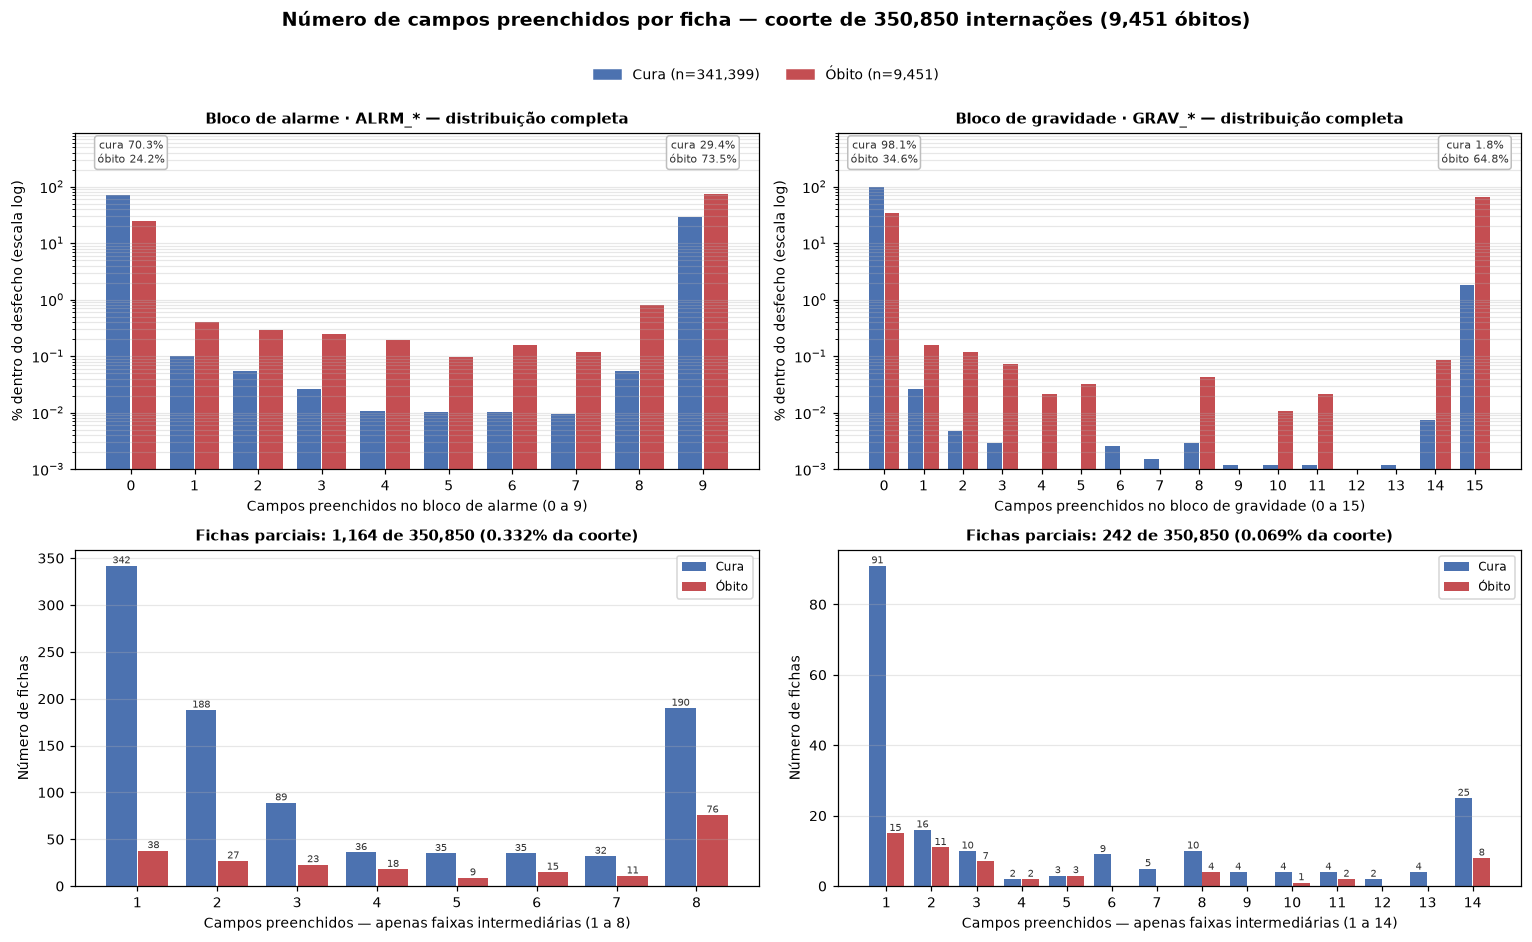

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))

for j, (nome, cfg) in enumerate(BLOCOS.items()):
    col, n_max = cfg['contagem'], cfg['n_campos']
    d = distribuicoes[distribuicoes['bloco'] == nome]
    x = d['n_campos_preenchidos'].to_numpy()

    # painel de cima: distribuicao completa, % dentro do desfecho, escala log
    ax = axes[0][j]
    ax.bar(x - 0.2, d['pct_cura'], width=0.38, color=COR_CURA, label=f'Cura (n={N_CURA:,})')
    ax.bar(x + 0.2, d['pct_obito'], width=0.38, color=COR_OBITO, label=f'Óbito (n={N_OBITO:,})')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, 900)
    ax.set_xticks(x)
    ax.set_xlabel(f'Campos preenchidos no bloco de {nome} (0 a {n_max})')
    ax.set_ylabel('% dentro do desfecho (escala log)')
    ax.set_title(f'Bloco de {nome} · {cfg["rotulo"]} — distribuição completa',
                 fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3, which='both')
    # rotulos dos extremos num unico texto, no topo do eixo, para nao colidir com as barras
    for xi, pc, po in zip(x, d['pct_cura'], d['pct_obito']):
        if xi in (0, n_max):
            ax.text(xi, 400, f'cura {pc:.1f}%\nóbito {po:.1f}%', ha='center', va='center',
                    fontsize=7.5, color='#333',
                    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#bbb', alpha=0.95))

    # painel de baixo: apenas as faixas intermediarias, em contagem
    ax = axes[1][j]
    di = d[(d['n_campos_preenchidos'] > 0) & (d['n_campos_preenchidos'] < n_max)]
    xi_ = di['n_campos_preenchidos'].to_numpy()
    ax.bar(xi_ - 0.2, di['n_cura'], width=0.38, color=COR_CURA, label='Cura')
    ax.bar(xi_ + 0.2, di['n_obito'], width=0.38, color=COR_OBITO, label='Óbito')
    ax.set_xticks(xi_)
    ax.set_xlabel(f'Campos preenchidos — apenas faixas intermediárias (1 a {n_max - 1})')
    ax.set_ylabel('Número de fichas')
    n_parc = int(di['n_total'].sum())
    ax.set_title(f'Fichas parciais: {n_parc:,} de {N_TOTAL:,} '
                 f'({n_parc / N_TOTAL * 100:.3f}% da coorte)', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    for xv, nc, no in zip(xi_, di['n_cura'], di['n_obito']):
        if nc:
            ax.text(xv - 0.2, nc, f'{int(nc)}', ha='center', va='bottom', fontsize=6.5, color='#333')
        if no:
            ax.text(xv + 0.2, no, f'{int(no)}', ha='center', va='bottom', fontsize=6.5, color='#333')

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=COR_CURA, label=f'Cura (n={N_CURA:,})'),
                    Patch(color=COR_OBITO, label=f'Óbito (n={N_OBITO:,})')],
           loc='upper center', bbox_to_anchor=(0.5, 0.955), ncol=2, fontsize=9,
           frameon=False)
plt.suptitle(f'Número de campos preenchidos por ficha — coorte de {N_TOTAL:,} internações '
             f'({N_OBITO:,} óbitos)', fontsize=12.5, fontweight='bold', y=1.0)
plt.tight_layout(rect=(0, 0, 1, 0.945))
salvar_fig(fig, 'histograma_campos_preenchidos_por_bloco.png')
plt.show()

Figura auxiliar: prevalência de óbito por grau de preenchimento, que é a leitura que distingue as fichas parciais dos dois extremos.

[figura] analysis/plots/preenchimento/prevalencia_por_grau_de_preenchimento.png


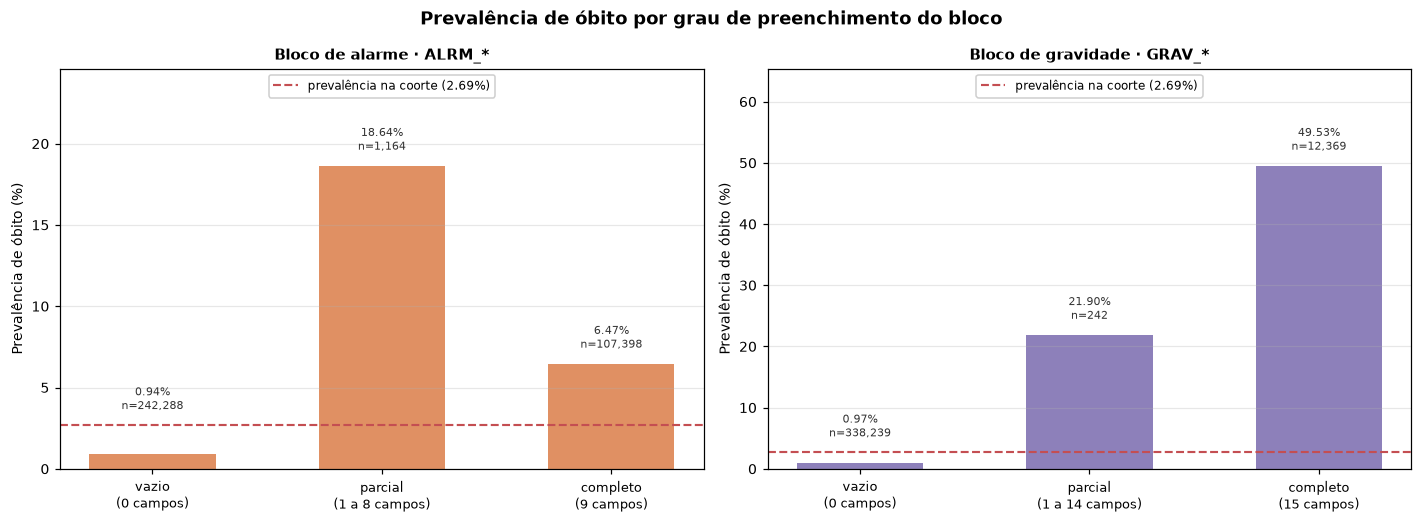

In [11]:
# Figura auxiliar: prevalencia de obito por grau de preenchimento
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
prev_coorte = N_OBITO / N_TOTAL * 100

for ax, (nome, cfg) in zip(axes, BLOCOS.items()):
    b = parciais[parciais['bloco'] == nome]
    x = np.arange(len(b))
    barras = ax.bar(x, b['prevalencia_obito_pct'], width=0.55, color=cfg['cor'], alpha=0.9)
    ax.axhline(prev_coorte, color=COR_OBITO, ls='--', lw=1.4,
               label=f'prevalência na coorte ({prev_coorte:.2f}%)')
    ax.set_xticks(x)
    ax.set_xticklabels([g.replace(' (', '\n(') for g in b['grupo']], fontsize=8.5)
    ax.set_ylabel('Prevalência de óbito (%)')
    ax.set_ylim(0, max(b['prevalencia_obito_pct'].max() * 1.32, 12))
    ax.set_title(f'Bloco de {nome} · {cfg["rotulo"]}', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='upper center', framealpha=0.95)
    folga = b['prevalencia_obito_pct'].max() * 0.04
    for barra, (_, r) in zip(barras, b.iterrows()):
        base = max(r['prevalencia_obito_pct'], prev_coorte)
        ax.text(barra.get_x() + barra.get_width() / 2, base + folga,
                f'{r["prevalencia_obito_pct"]:.2f}%\nn={int(r["n"]):,}',
                ha='center', va='bottom', fontsize=7.5, color='#333')

plt.suptitle('Prevalência de óbito por grau de preenchimento do bloco',
             fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'prevalencia_por_grau_de_preenchimento.png')
plt.show()

## Conclusões

- O preenchimento é tudo-ou-nada em ambos os blocos.
  Os dois extremos somam 99,7% da coorte no bloco de alarme, com 69,1% de fichas vazias e 30,6% completas, e 99,9% no bloco de gravidade, com 96,4% vazias e 3,5% completas.

- As fichas com preenchimento intermediário são residuais: 1.164 no bloco de alarme, 0,3% da coorte, e 242 no de gravidade, 0,1%.

- As fichas parciais não se comportam como nenhum dos dois extremos, e é por isso que a escolha entre as definições não é indiferente.
  No bloco de alarme a prevalência de óbito é de 18,6% nas parciais, contra 0,9% nas vazias e 6,5% nas completas, de modo que as parciais superam os dois extremos.
  No bloco de gravidade é de 21,9% nas parciais, contra 1,0% nas vazias e 49,5% nas completas, ficando entre os dois.

- As definições (a) e (b) quase coincidem: a correlação φ entre elas é de 0,992 no bloco de alarme e 0,990 no de gravidade, e discordam exatamente nas fichas parciais, 1.164 e 242 registros.

- A correlação com o desfecho separa pouco as três definições, e a ordem se inverte entre os blocos.
  No bloco de alarme (a) alcança 0,1614, acima de (c) com 0,1588 e de (b) com 0,1548.
  No de gravidade (c) alcança 0,5535, à frente de (b) com 0,5531 e de (a) com 0,5523.

- A definição (a) é a que recolhe as fichas parciais junto com as completas: 108.562 positivos no bloco de alarme contra 107.398 em (b), e 12.611 contra 12.369 no de gravidade.

- Os dois blocos não são preenchidos em conjunto: a correlação φ entre eles é de 0,2633.
  O alarme é preenchido sem a gravidade em 96.710 fichas, 27,6% da coorte, com prevalência de óbito de 1,5%, enquanto a gravidade sem o alarme ocorre em 759 fichas, 0,2%, com prevalência de 59,4%.

- Dentro das fichas parciais há campos que costumam ser preenchidos isoladamente: `ALRM_PLAQ` aparece em 70,5% das parciais do bloco de alarme e `GRAV_PULSO` em 47,1% das do bloco de gravidade, contra cerca de 30,8% e 3,6% de preenchimento na coorte inteira.

- A coorte tem 350.850 registros, com 9.451 óbitos, 2,7% de letalidade, e as contagens médias por ficha são de 2,767 campos no bloco de alarme e 0,532 no de gravidade.